<a href="https://colab.research.google.com/github/Ana-Beatriz-N/ProcessamentoDeImagens/blob/main/Portfolio2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
arquivo = files.upload()

Saving regular.jpeg to regular.jpeg
Saving clara.jpeg to clara.jpeg
Saving escura.jpeg to escura.jpeg


In [ ]:
img_regular = cv2.imread('regular.jpeg')
img_clara = cv2.imread('clara.jpeg')
img_escura = cv2.imread('escura.jpeg')

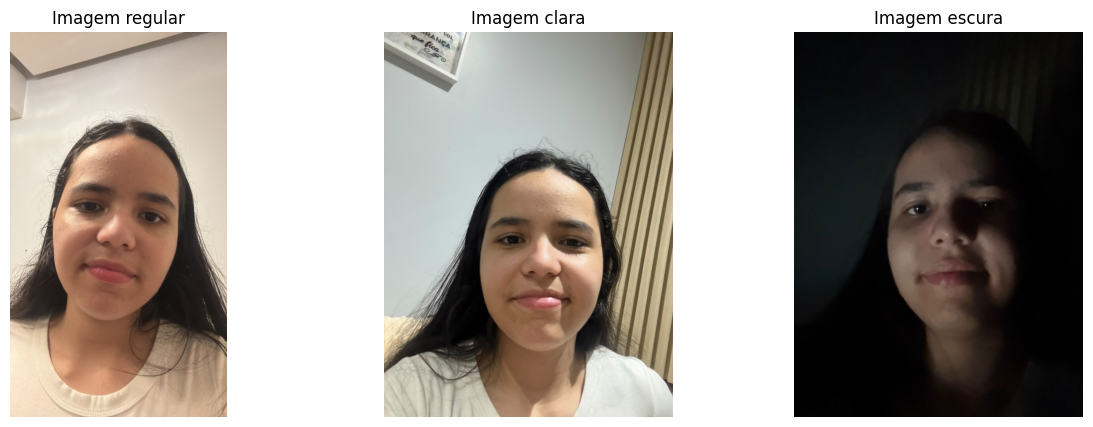

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(img_regular, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagem regular")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_clara, cv2.COLOR_BGR2RGB))
axes[1].set_title("Imagem clara")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_escura, cv2.COLOR_BGR2RGB))
axes[2].set_title("Imagem escura")
axes[2].axis("off")

plt.show()

In [ ]:
def calc_hist(img):
    img_vetor = img.ravel()
    hist_vetor = np.zeros(256, dtype=np.int64)

    for px in img_vetor:
        hist_vetor[px] += 1

    return hist_vetor


def expandir_contraste(img, L, H):
    img_float = img.astype(np.float32)
    img_float = np.clip(img_float, L, H)
    img_expandida = ((img_float - L) / (H - L)) * 255
    return img_expandida.astype(np.uint8)


def equalizar(img):
    return cv2.equalizeHist(img)


def corrigir_gamma(img, gamma):
    tabela = np.array([
        ((i / 255.0) ** gamma) * 255
        for i in np.arange(256)
    ]).astype("uint8")

    return cv2.LUT(img, tabela)


def mostrar_resultado(original, resultado, titulo_original, titulo_resultado):
    hist_original = calc_hist(original)
    hist_resultado = calc_hist(resultado)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title(titulo_original)
    axes[0, 0].axis('off')

    axes[0, 1].imshow(resultado, cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title(titulo_resultado)
    axes[0, 1].axis('off')

    axes[1, 0].bar(range(256), hist_original)
    axes[1, 0].set_title("Histograma - Antes")
    axes[1, 0].set_xlim(0, 255)

    axes[1, 1].bar(range(256), hist_resultado)
    axes[1, 1].set_title("Histograma - Depois")
    axes[1, 1].set_xlim(0, 255)

    plt.tight_layout()
    plt.show()

In [ ]:
gray_regular = cv2.cvtColor(img_regular, cv2.COLOR_BGR2GRAY)
gray_clara = cv2.cvtColor(img_clara, cv2.COLOR_BGR2GRAY)
gray_escura = cv2.cvtColor(img_escura, cv2.COLOR_BGR2GRAY)

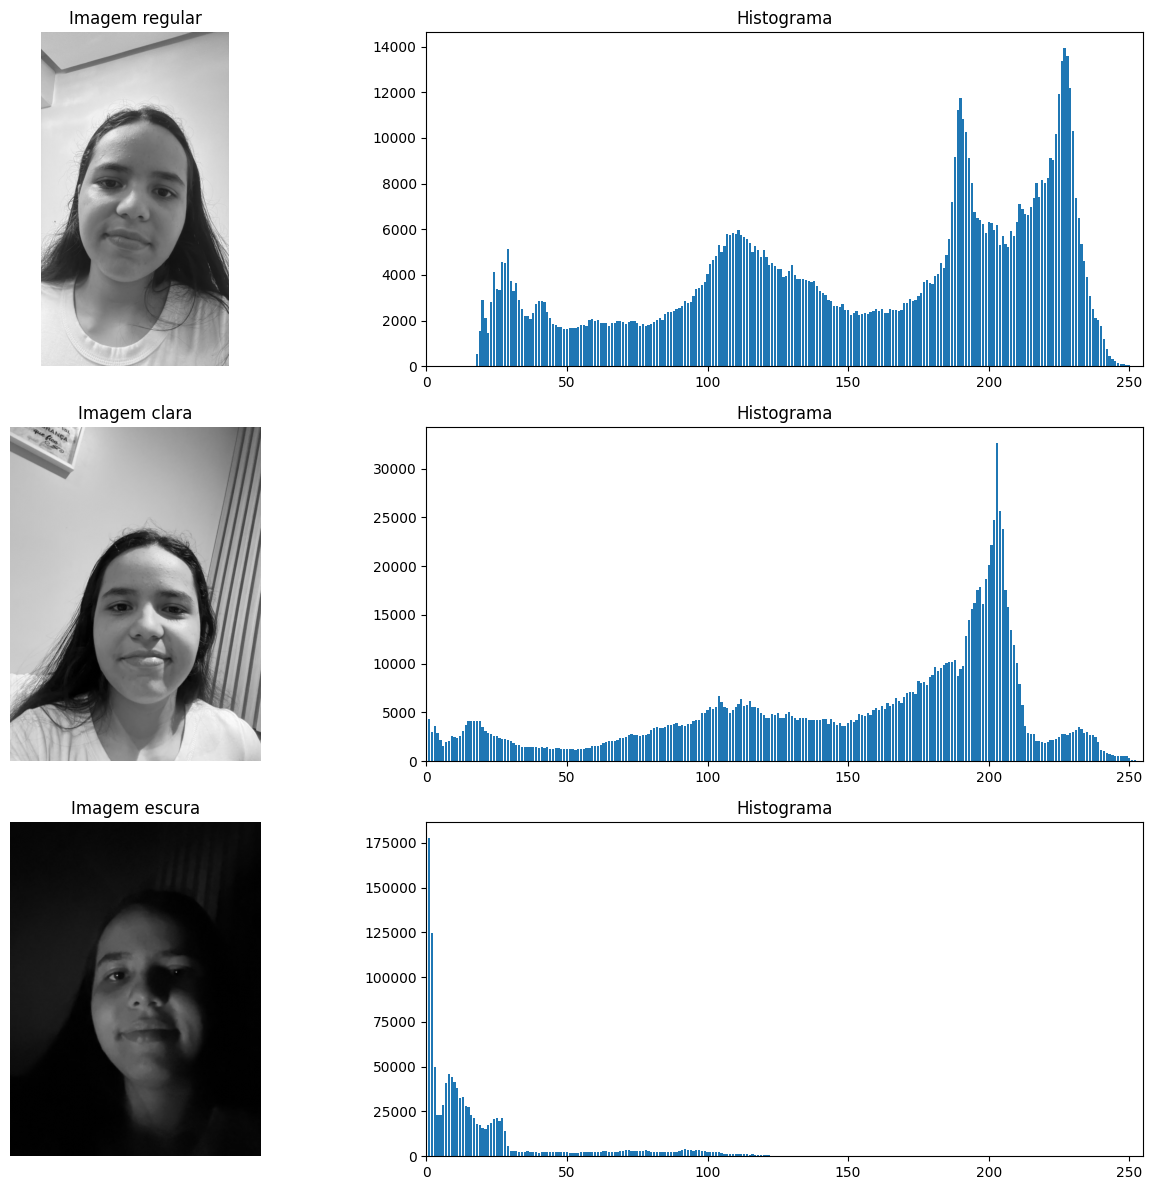

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

imagens = [
    (gray_regular, "Imagem regular"),
    (gray_clara, "Imagem clara"),
    (gray_escura, "Imagem escura")
]

for i, (img, titulo) in enumerate(imagens):
    axes[i, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[i, 0].set_title(titulo)
    axes[i, 0].axis('off')

    hist = calc_hist(img)
    axes[i, 1].bar(range(256), hist)
    axes[i, 1].set_title("Histograma")
    axes[i, 1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

Imagem regular: O histograma apresenta intensidades distribuídas em uma faixa ampla, aproximadamente entre 20 e 240, com maior concentração nos tons médios e claros, entre 10 e 230. Isso indica uma imagem com bom equilíbrio de brilho e contraste, preservando detalhes tanto nas regiões escuras quanto nas claras.

Imagem clara: As intensidades estão fortemente concentradas entre 170 e 220, com um pico acentuado próximo de 200. Essa distribuição indica uma imagem superexposta ou muito iluminada, com predominância de tons claros e possível perda de detalhes nas áreas mais brilhantes.

Imagem escura: O histograma está concentrado principalmente entre 0 e 40, com poucos pixels em intensidades mais altas. Isso indica uma imagem subexposta, dominada por tons escuros e com perda de detalhes nas regiões de baixa iluminação.

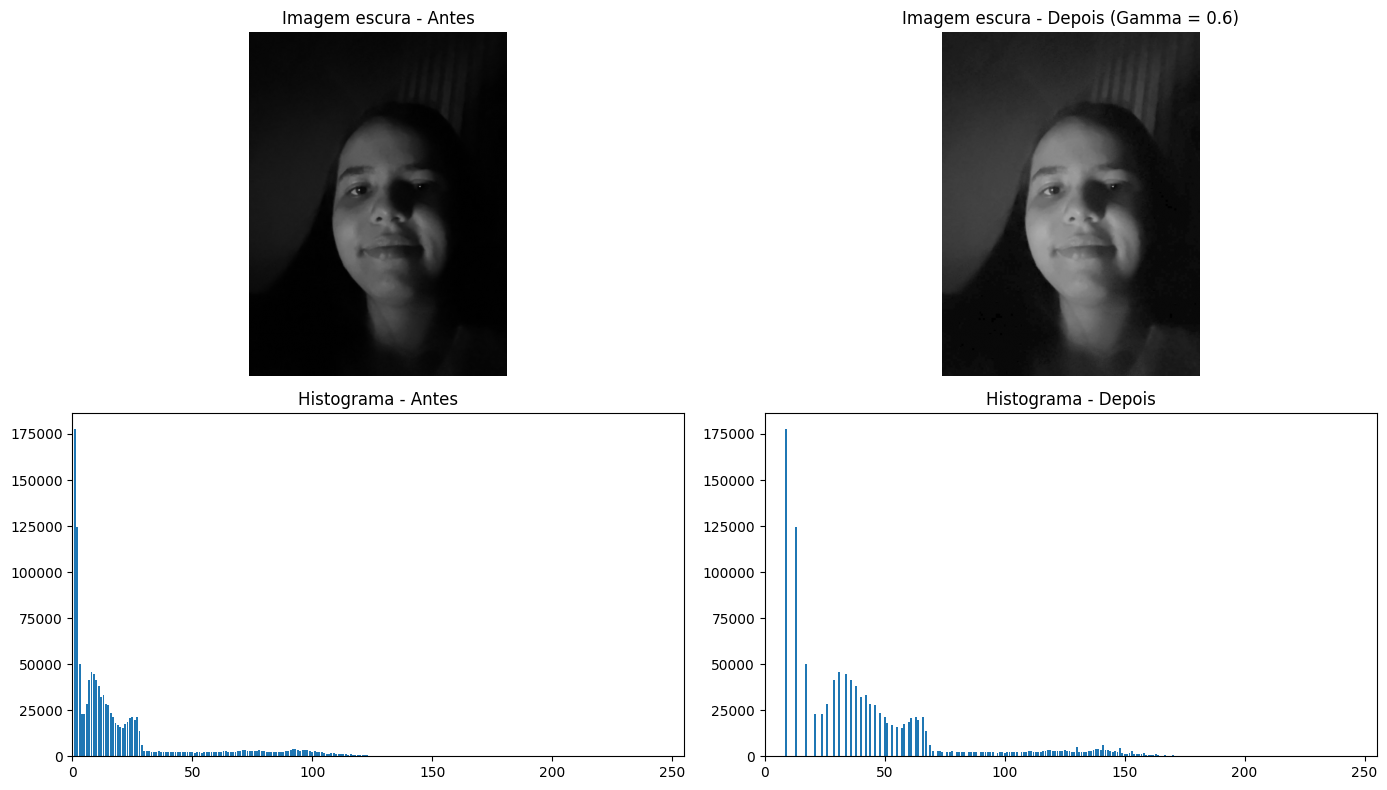

In [ ]:
escura_corrigida = corrigir_gamma(gray_escura, 0.6)

mostrar_resultado(
    gray_escura,
    escura_corrigida,
    "Imagem escura - Antes",
    "Imagem escura - Depois (Gamma = 0.6)"
)

Optou-se pela aplicação da correção de gamma com γ = 0,6, pois a imagem possui uma quantidade significativa de pixels em tons escuros, conforme observado no histograma. Como valores de gamma inferiores a 1 clareiam principalmente as regiões de baixa intensidade, essa configuração foi utilizada para tornar mais visíveis os detalhes da pessoa e do cenário que estavam pouco perceptíveis na imagem original.

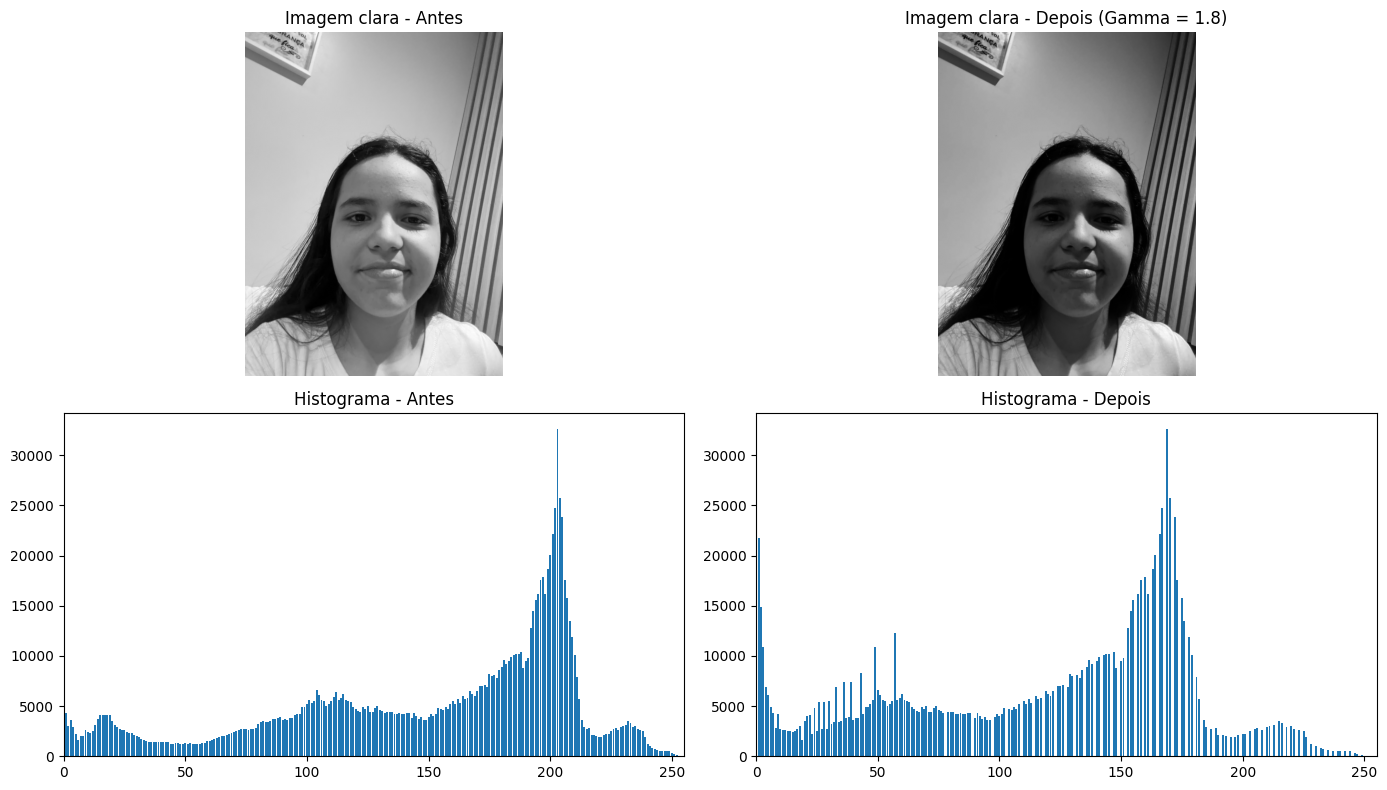

In [ ]:
clara_corrigida = corrigir_gamma(gray_clara, 1.8)

mostrar_resultado(
    gray_clara,
    clara_corrigida,
    "Imagem clara - Antes",
    "Imagem clara - Depois (Gamma = 1.8)"
)

Para essa imagem, foi escolhida a correção de gamma com γ = 1,8, devido à predominância de intensidades altas e à presença de muitos pixels próximos às regiões mais claras. O uso de um gamma superior a 1 permite reduzir essas intensidades, ajudando a controlar a luminosidade excessiva e a recuperar detalhes que estavam pouco definidos nas áreas claras.

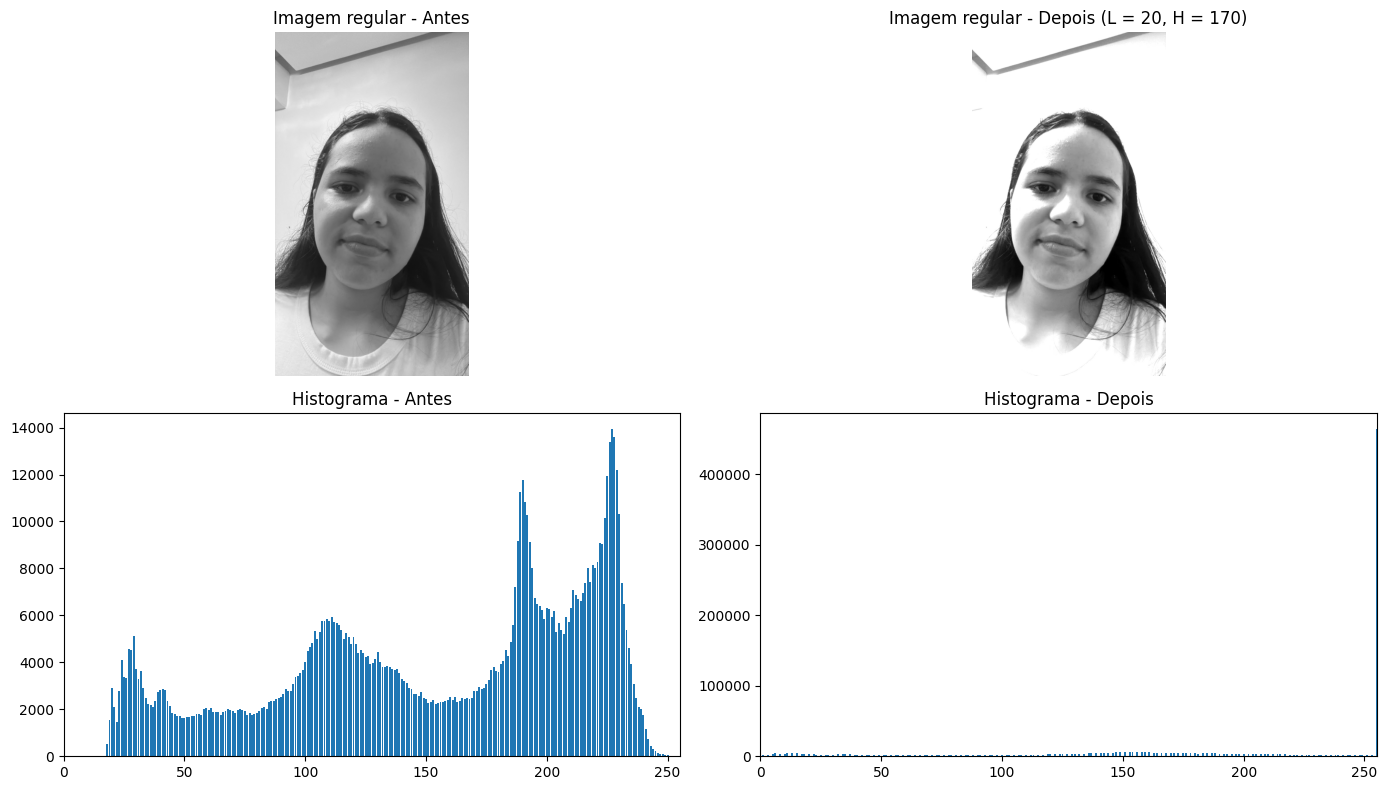

In [ ]:
regular_corrigida = expandir_contraste(gray_regular, 20, 170)

mostrar_resultado(
    gray_regular,
    regular_corrigida,
    "Imagem regular - Antes",
    "Imagem regular - Depois (L = 20, H = 170)"
)

Foi aplicada a expansão de contraste utilizando L = 20 e H = 170, pois a imagem apresentava uma distribuição de intensidades relativamente equilibrada, concentrada principalmente em uma faixa intermediária. Foram testados inicialmente os valores L = 10 e H = 245, mas eles provocaram uma alteração muito intensa no contraste, prejudicando o aspecto visual da fotografia. Assim, os valores escolhidos proporcionaram um ajuste mais moderado, aumentando a diferença entre os tons sem causar uma degradação significativa da imagem.

A operação teve um efeito menos evidente na imagem regular, pois ela já possuía uma iluminação adequada e uma distribuição de intensidades relativamente uniforme no histograma. Dessa forma, a expansão de contraste com L = 20 e H = 170 resultou em uma mudança mais suave, enquanto as imagens clara e escura exigiram ajustes mais significativos para corrigir, respectivamente, o excesso e a deficiência de luminosidade.